In [17]:
import pandas as pd
import numpy as np
import sys
import os

import src.constants as const
from src.logger import logging
from src.components.data_ingestion import IngestaDatos
from src.exception import ExcepcionPersonalizada

import matplotlib.pyplot as plt
import seaborn as sns

### Carga del DataFrame

In [18]:
from numpy import shape
from logging import disable
def cargar_datos():
    try:
        logging.info("Cargando dataset para realizar exploración (EDA)")

        if not const.ARCHIVO_OBJETIVO.exists():
            raise FileNotFoundError(f"El archivo no se encuentra en {const.ARCHIVO_OBJETIVO}")
        
        df = pd.read_csv(const.ARCHIVO_OBJETIVO)

        logging.info("Dataset cargado exitosamente para EDA")
        return df

    except Exception as e:
        raise ExcepcionPersonalizada(e, sys)

df = cargar_datos()

print(f"El dataset se conforma por {df.shape[1]} columnas y {df.shape[0]} filas.")

El dataset se conforma por 24 columnas y 2000 filas.


In [19]:
df.head()

,brand,model,year,variant,price_usd,battery_capacity_kwh,range_miles,charging_speed_kw,acceleration_0_60_mph,top_speed_mph,...,body_type,cargo_volume_cubic_ft,weight_kg,safety_rating,autopilot_level,country_of_origin,market_segment,annual_sales_units,customer_rating,warranty_years
0,Volkswagen,ID. Buzz,2023,Performance,104880.80,118.7,400.0,234.5,3.04,195.0,...,Truck,54.2,2015.0,4,2,Germany,Luxury,202182,4.00,4
1,Toyota,bZ Compact SUV,2022,Premium,48217.41,58.8,219.0,148.1,5.77,159.0,...,SUV,69.0,1709.0,4,0,Japan,Mid-range,7146,3.56,3
2,GM/Chevrolet,Bolt EV,2024,Premium,49651.12,58.2,225.0,104.9,6.84,148.0,...,Van,77.0,1533.0,4,1,US,Mid-range,16590,3.70,3
3,Kia,Sportage EV,2024,Long Range,38131.56,102.5,349.0,66.5,4.66,176.0,...,SUV,65.8,1935.0,4,2,South Korea,Mid-range,127201,3.81,3
4,Tesla,Model 3,2022,Long Range,144079.87,93.9,314.0,298.5,5.64,165.0,...,SUV,38.3,2229.0,4,2,US,Luxury,196401,3.83,4


In [21]:
def renombrar_columnas(df):
    try:
        logging.info("Renombrando columnas a español")

        # Mapeo de nombres: 'nombre_originl': 'nuevo_nombre'
        traduccion_columnas = {
            'brand': 'marca',
            'model': 'modelo',
            'year': 'anio',
            'variant': 'variante',
            'price_usd': 'precio_usd',
            'battery_capacity_kwh': 'capacidad_bateria_kwh',
            'range_miles': 'autonomia_millas',
            'charging_speed_kw': 'velocidad_carga_kw',
            'acceleration_0_60_mph': 'aceleracion_0_60_mph',
            'top_speed_mph': 'velocidad_maxima_mph',
            'horsepower': 'caballos_fuerza',
            'torque_nm': 'torque_nm',
            'drive_type': 'tipo_traccion',
            'seating_capacity': 'capacidad_asientos',
            'body_type': 'tipo_carroceria',
            'cargo_volume_cubic_ft': 'volumen_carga_pies_cubicos',
            'weight_kg': 'peso_kg',
            'safety_rating': 'calificacion_seguridad',
            'autopilot_level': 'nivel_autopiloto',
            'country_of_origin': 'pais_origen',
            'market_segment': 'segmento_mercado',
            'annual_sales_units': 'ventas_anuales_unidades',
            'customer_rating': 'valoracion_clientes',
            'warranty_years': 'anios_garantia'
        }

        df.rename(columns= traduccion_columnas,inplace= True)
        logging.info("Columnas renombradas exitosamente")
        return df
    
    except Exception as e:
        raise ExcepcionPersonalizada(e, sys)

df = renombrar_columnas(df)
df.head()

,marca,modelo,anio,variante,precio_usd,capacidad_bateria_kwh,autonomia_millas,velocidad_carga_kw,aceleracion_0_60_mph,velocidad_maxima_mph,...,tipo_carroceria,volumen_carga_pies_cubicos,peso_kg,calificacion_seguridad,nivel_autopiloto,pais_origen,segmento_mercado,ventas_anuales_unidades,valoracion_clientes,anios_garantia
0,Volkswagen,ID. Buzz,2023,Performance,104880.80,118.7,400.0,234.5,3.04,195.0,...,Truck,54.2,2015.0,4,2,Germany,Luxury,202182,4.00,4
1,Toyota,bZ Compact SUV,2022,Premium,48217.41,58.8,219.0,148.1,5.77,159.0,...,SUV,69.0,1709.0,4,0,Japan,Mid-range,7146,3.56,3
2,GM/Chevrolet,Bolt EV,2024,Premium,49651.12,58.2,225.0,104.9,6.84,148.0,...,Van,77.0,1533.0,4,1,US,Mid-range,16590,3.70,3
3,Kia,Sportage EV,2024,Long Range,38131.56,102.5,349.0,66.5,4.66,176.0,...,SUV,65.8,1935.0,4,2,South Korea,Mid-range,127201,3.81,3
4,Tesla,Model 3,2022,Long Range,144079.87,93.9,314.0,298.5,5.64,165.0,...,SUV,38.3,2229.0,4,2,US,Luxury,196401,3.83,4


In [26]:
valores_nulos = df.isnull().sum()
valores_duplicados = df.duplicated().sum()

print(f"Cantidad de valores nulos:\n{valores_nulos}")
print(f"\nCantidad de valores duplicados: {valores_duplicados}")

Cantidad de valores nulos:
marca                         0
modelo                        0
anio                          0
variante                      0
precio_usd                    0
capacidad_bateria_kwh         0
autonomia_millas              0
velocidad_carga_kw            0
aceleracion_0_60_mph          0
velocidad_maxima_mph          0
caballos_fuerza               0
torque_nm                     0
tipo_traccion                 0
capacidad_asientos            0
tipo_carroceria               0
volumen_carga_pies_cubicos    0
peso_kg                       0
calificacion_seguridad        0
nivel_autopiloto              0
pais_origen                   0
segmento_mercado              0
ventas_anuales_unidades       0
valoracion_clientes           0
anios_garantia                0
dtype: int64

Cantidad de valores duplicados: 0


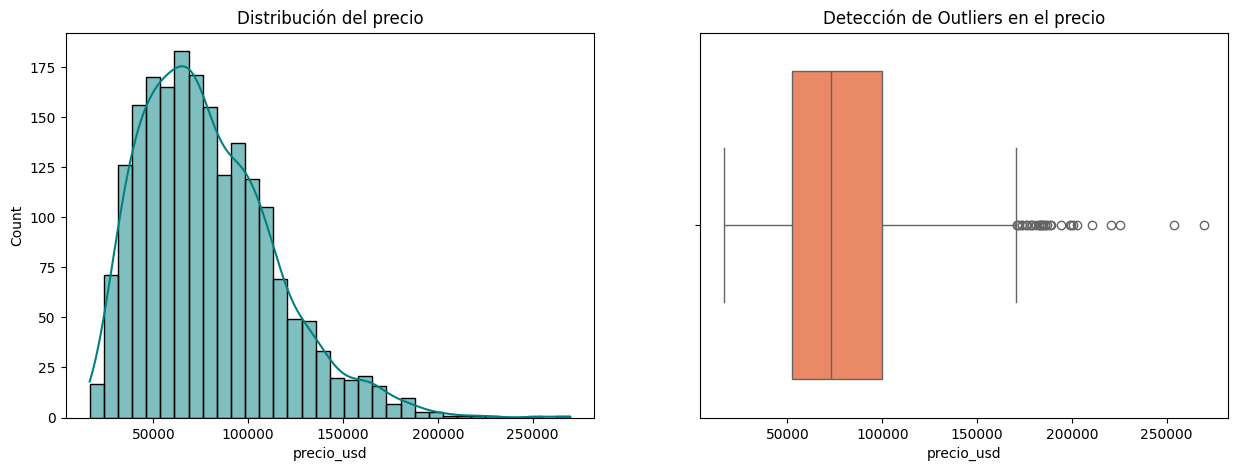

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['precio_usd'], kde=True, color='teal', ax=axes[0])
axes[0].set_title('Distribución del precio')

sns.boxplot(x=df['precio_usd'], color='coral', ax=axes[1])
axes[1].set_title('Detección de Outliers en el precio')

plt.show()